# Notebook 02 — Feature Engineering
## JFK Airport Daily Passenger Throughput Forecasting

This notebook transforms the merged dataset from Notebook 01 into a
model-ready feature matrix.

**Input:** `data/processed/jfk_daily_merged.csv` (2,345 rows × 30 columns)

**Output:** `data/processed/jfk_modeling_ready.csv` (~1,978 rows × 54 features)

**Design decisions** are documented in `feature_engineering_decisions.md`.

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json
from datetime import date, timedelta
import holidays

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

FIGURES = '../reports/figures'
os.makedirs(FIGURES, exist_ok=True)

print('Setup complete.')

## 2. Load Merged Dataset from Notebook 01

In [ ]:
df = pd.read_csv('../data/processed/jfk_daily_merged.csv', parse_dates=['Date'])
print(f'Shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Date between: {(df.Date.max() - df.Date.min()).days + 1}')
print(f'Columns ({df.shape[1]}): {list(df.columns)}')
df.head(3)

## 3. Drop Unnecessary Columns

Terminal-level columns were used for EDA only: the target `daily_throughput`
is already the sum. We also drop `scheduled_arrivals` and
`total_scheduled_flights` per
[Decision #1](feature_engineering_decisions.md#1-scheduled-departures-only-not-arrivals):
TSA screens only departing passengers, and departures/arrivals are r ≈ 0.99
correlated.

In [ ]:
# Drop terminal columns
terminal_cols = [c for c in df.columns if 'Terminal' in c]
df = df.drop(columns=terminal_cols)
print(f'Dropped {len(terminal_cols)} terminal columns: {terminal_cols}')

# Drop arrivals and total flights (Decision #1 — departures only)
flight_drop = ['scheduled_arrivals', 'total_scheduled_flights']
flight_drop = [c for c in flight_drop if c in df.columns]
df = df.drop(columns=flight_drop)
print(f'Dropped flight columns: {flight_drop}')

print(f'\nRemaining: {df.shape[1]} columns: {list(df.columns)}')

## 4. Calendar Features (Cyclical Encoding)

Per [Decision #5](feature_engineering_decisions.md#5-cyclical-encoding-for-calendar-features),
we encode `day_of_week`, `month`, and `day_of_year` with sin/cos transforms
to preserve circularity (Sunday↔Monday, December↔January).

We also add `is_weekend` as a binary feature.

In [ ]:
# Extract raw calendar values
df['day_of_week'] = df['Date'].dt.dayofweek      # 0=Mon, 6=Sun
df['month']       = df['Date'].dt.month           # 1-12
df['day_of_year'] = df['Date'].dt.dayofyear       # 1-366
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

# Cyclical sin/cos encoding
def cyclical_encode(df, col, period):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period)
    return df

df = cyclical_encode(df, 'day_of_week', 7)
df = cyclical_encode(df, 'month', 12)

# day_of_year: use actual year length (365 or 366) for correct alignment
days_in_year = df['Date'].dt.is_leap_year.map({True: 366, False: 365})
df = cyclical_encode(df, 'day_of_year', days_in_year)

# Drop raw integer versions (keep only sin/cos + is_weekend)
# quarter is dropped entirely — redundant with month encoding (Decision #6)
df = df.drop(columns=['day_of_week', 'month', 'day_of_year'])

calendar_features = ['is_weekend',
                     'day_of_week_sin', 'day_of_week_cos',
                     'month_sin', 'month_cos',
                     'day_of_year_sin', 'day_of_year_cos']
print(f'Calendar features ({len(calendar_features)}): {calendar_features}')

## 5. Holiday Features

We use the `holidays` library to generate US federal holidays, which correctly
handles **observed dates** (e.g., when July 4th falls on Saturday, Friday is
the observed holiday because the day that actually shifts airport demand). We then
add travel-period flags for major holiday seasons.

In [ ]:
# ── US Federal Holidays via holidays library ──
# Handles observed dates automatically (e.g., Jul 4 on Sat → Fri observed)
years = range(df['Date'].dt.year.min(), df['Date'].dt.year.max() + 1)
us_hols = holidays.US(years=years)

holiday_dates = set(us_hols.keys())

# ── Basic holiday flags ──
df['is_holiday'] = df['Date'].dt.date.isin(holiday_dates).astype(int)

# is_long_weekend: is this day part of a 3-day weekend created by a Mon/Fri holiday?
def is_long_weekend_day(dt):
    d = dt.date()
    for hol_date in holiday_dates:
        dow = hol_date.weekday()
        if dow == 0:  # Monday holiday → Sat/Sun/Mon
            if hol_date - timedelta(days=2) <= d <= hol_date:
                return 1
        elif dow == 4:  # Friday holiday → Fri/Sat/Sun
            if hol_date <= d <= hol_date + timedelta(days=2):
                return 1
    return 0

df['is_long_weekend'] = df['Date'].apply(is_long_weekend_day)

print(f'Federal holidays in range: {len(us_hols)}')
print(f'Holiday days in dataset: {df["is_holiday"].sum()}')
print(f'Long weekend days in dataset: {df["is_long_weekend"].sum()}')
print(f'\nSample holidays:')
for d, name in sorted(us_hols.items())[:10]:
    print(f'  {d}: {name}')

### 5.1 Holiday Travel Period Flags

Airport demand surges don't just happen on the holiday itself, they aslo span
multi-day travel windows. We flag the peak travel periods around major
holidays.

In [ ]:
def thanksgiving_period(dt):
    """Tue before Thanksgiving through Sun after (6 days)."""
    y = dt.year
    # Find Thanksgiving: 4th Thursday in November
    d = date(y, 11, 1)
    d += timedelta(days=(3 - d.weekday()) % 7)  # first Thursday
    tg = d + timedelta(weeks=3)
    start = tg - timedelta(days=2)   # Tuesday before
    end = tg + timedelta(days=3)     # Sunday after
    return int(start <= dt.date() <= end)

def christmas_period(dt):
    """Dec 20 – Jan 2 (captures both Christmas and New Year travel)."""
    d = dt.date()
    if d.month == 12 and d.day >= 20:
        return 1
    if d.month == 1 and d.day <= 2:
        return 1
    return 0

def july4_period(dt):
    """Jul 1 – Jul 7 (week around Independence Day)."""
    d = dt.date()
    return int(d.month == 7 and 1 <= d.day <= 7)

def spring_break_period(dt):
    """Mid-March to mid-April (broad spring break window)."""
    d = dt.date()
    return int((d.month == 3 and d.day >= 15) or (d.month == 4 and d.day <= 15))

df['period_thanksgiving'] = df['Date'].apply(thanksgiving_period)
df['period_christmas']    = df['Date'].apply(christmas_period)
df['period_july4']        = df['Date'].apply(july4_period)
df['period_spring_break'] = df['Date'].apply(spring_break_period)

holiday_features = ['is_holiday', 'is_long_weekend',
                    'period_thanksgiving', 'period_christmas',
                    'period_july4', 'period_spring_break']
print(f'Holiday features ({len(holiday_features)}): {holiday_features}')
for f in holiday_features:
    print(f'  {f}: {df[f].sum()} days flagged')

## 6. Autoregressive Features (Lags)

Lags provide the model with recent throughput history. We use lags of 1, 7,
14, and 28 days. The year-over-year signal is captured separately in §7.

In [ ]:
# Sort by date to ensure correct lag computation
df = df.sort_values('Date').reset_index(drop=True)

lag_days = [1, 7, 14, 28]
for lag in lag_days:
    df[f'lag_{lag}'] = df['daily_throughput'].shift(lag)

lag_features = [f'lag_{d}' for d in lag_days]
print(f'Lag features ({len(lag_features)}): {lag_features}')
print(f'NaN introduced: lag_28 creates {df["lag_28"].isna().sum()} NaN rows')

## 7. Same-Weekday-Last-Year

Per [Decision #3](feature_engineering_decisions.md#3-same-weekday-last-year-not-lag_365),
we compute the mean throughput of the same weekday in the same month of the
prior year. 

**Cost:** ~365 rows lost to NaN 

In [ ]:
def same_weekday_last_year(df):
    """For each row, average throughput of same weekday in same month, prior year."""
    df = df.copy()
    df['_year'] = df['Date'].dt.year
    df['_month'] = df['Date'].dt.month
    df['_dow'] = df['Date'].dt.dayofweek

    # Build lookup: (year, month, dow) -> mean throughput
    lookup = (df.groupby(['_year', '_month', '_dow'])['daily_throughput']
              .mean()
              .to_dict())

    # For each row, look up (year-1, month, dow)
    df['same_weekday_last_year'] = df.apply(
        lambda r: lookup.get((r['_year'] - 1, r['_month'], r['_dow']), np.nan),
        axis=1
    )

    df = df.drop(columns=['_year', '_month', '_dow'])
    return df

df = same_weekday_last_year(df)

n_nan = df['same_weekday_last_year'].isna().sum()
print(f'same_weekday_last_year: {n_nan} NaN rows (first year without prior reference)')
print(f'Sample values (non-NaN):')
print(df[df['same_weekday_last_year'].notna()][['Date', 'daily_throughput', 'same_weekday_last_year']].head())

## 8. Rolling Statistics

Rolling windows capture recent trend and volatility. We compute mean, std,
min, and max over 7-, 14-, and 30-day windows.

**Important:** We use `.shift(1)` before rolling to avoid target leakage.

In [ ]:
# Shift throughput by 1 to prevent leakage (window ends at day t-1)
shifted = df['daily_throughput'].shift(1)

windows = [7, 14, 30]
for w in windows:
    roll = shifted.rolling(window=w, min_periods=w)
    df[f'roll_mean_{w}']  = roll.mean()
    df[f'roll_std_{w}']   = roll.std()
    df[f'roll_min_{w}']   = roll.min()
    df[f'roll_max_{w}']   = roll.max()

rolling_features = [f'roll_{stat}_{w}' for w in windows for stat in ['mean', 'std', 'min', 'max']]
print(f'Rolling features ({len(rolling_features)}): {rolling_features}')
print(f'NaN from roll_mean_30: {df["roll_mean_30"].isna().sum()} rows')

## 9. Differencing Features

Differencing captures momentum and trend changes at different time scales.

In [ ]:
# Day-over-day change
df['diff_1'] = df['daily_throughput'].diff(1)

# Week-over-week change (same day last week)
df['diff_7'] = df['daily_throughput'].diff(7)

# Year-over-year change (364 days to stay aligned on same weekday)
# df['diff_364'] = df['daily_throughput'].diff(364)

diff_features = ['diff_1', 'diff_7'] 
print(f'Differencing features ({len(diff_features)}): {diff_features}')

## 10. COVID Dummy Variables

Per [Decision #2](feature_engineering_decisions.md#2-three-level-covid-encoding-not-continuous-curve):
three-level encoding with normal operations as baseline.

- `covid_acute`: Mar 15, 2020 – Jun 30, 2020 (lockdowns, near-zero traffic)
- `covid_recovery`: Jul 1, 2020 – Jun 30, 2022 (gradual return)
- Baseline (both = 0): Normal operations

In [ ]:
df['covid_acute'] = ((df['Date'] >= '2020-03-15') &
                     (df['Date'] <= '2020-06-30')).astype(int)

df['covid_recovery'] = ((df['Date'] >= '2020-07-01') &
                        (df['Date'] <= '2022-06-30')).astype(int)

covid_features = ['covid_acute', 'covid_recovery']
print(f'COVID features: {covid_features}')
print(f'  covid_acute days:    {df["covid_acute"].sum()}')
print(f'  covid_recovery days: {df["covid_recovery"].sum()}')
print(f'  normal (baseline):   {(~(df["covid_acute"] | df["covid_recovery"]).astype(bool)).sum()}')

## 11. Handle Missing Values & Final Cleanup

Feature engineering introduced NaN rows from lags, rolling windows, and
same-weekday-last-year. The largest source is same_weekday_last_year (~365
rows). We drop all rows with any NaN in engineered features.

We also fill minor weather NaNs (AWND, WSF2, WSF5) and scheduled_departures
before dropping.

In [ ]:
# Fill minor weather NaNs with forward-fill then backward-fill
weather_cols = ['AWND', 'PRCP', 'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN',
                'WSF2', 'WSF5', 'WT01', 'WT02', 'WT03', 'WT04', 'WT05',
                'WT06', 'WT08', 'WT09']
for col in weather_cols:
    if col in df.columns:
        df[col] = df[col].ffill().bfill()

In [ ]:
# Report NaN status before dropping
print('NaN counts before dropping rows:')
nan_counts = df.isna().sum()
print(nan_counts[nan_counts > 0].to_string())

# cut out null values bought from same_weekday_last_year 
n_before = len(df)
last_null_date = df.loc[df['same_weekday_last_year'].isna(), 'Date'].max()
df = df[df.Date > last_null_date]
n_after = len(df)
print(f'\nDropped {n_before - n_after} rows ({n_before} -> {n_after})')
print(f'Date range after: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'   include {(df.Date.max() - df.Date.min()).days + 1} days and {len(df)} lines')

## 12. Define Feature Sets A and B

Per [Decision #4](feature_engineering_decisions.md#4-sarimax-uses-a-separate-feature-set):

- **Set A (SARIMAX):** Exogenous features only: calendar, holidays, weather,
  scheduled_departures, COVID dummies. No lags, rolling, or differencing.
- **Set B (all other models):** All features: Set A + autoregressive + rolling + differencing + same_weekday_last_year.

In [ ]:
# ── Define feature groups ──
flight_features = ['scheduled_departures'] if 'scheduled_departures' in df.columns else []

weather_features = [c for c in df.columns
                    if c.startswith(('AWND', 'PRCP', 'SNOW', 'SNWD', 'TAVG',
                                    'TMAX', 'TMIN', 'WSF', 'WT'))]

autoregressive_features = (lag_features + ['same_weekday_last_year']
                           + rolling_features + diff_features)

# Set A: exogenous only (for SARIMAX)
feature_set_A = (calendar_features + holiday_features + weather_features
                 + flight_features + covid_features)

# Set B: all features (for other models)
feature_set_B = feature_set_A + autoregressive_features

# Verify no duplicates
assert len(feature_set_A) == len(set(feature_set_A)), 'Duplicates in Set A!'
assert len(feature_set_B) == len(set(feature_set_B)), 'Duplicates in Set B!'

# Verify all features exist in df
missing_A = [f for f in feature_set_A if f not in df.columns]
missing_B = [f for f in feature_set_B if f not in df.columns]
assert not missing_A, f'Missing from df: {missing_A}'
assert not missing_B, f'Missing from df: {missing_B}'

print(f'Feature Set A (SARIMAX):      {len(feature_set_A)} features')
print(f'Feature Set B (all others):   {len(feature_set_B)} features')
print(f'Autoregressive-only features: {len(autoregressive_features)}')
print()
print('Set A features:')
for f in feature_set_A:
    print(f'  {f}')
print()
print('Additional features in Set B (autoregressive):')
for f in autoregressive_features:
    print(f'  {f}')

### 12.1 Ablation Study Feature Groups (for RQ3)

In [ ]:
# Save ablation group definitions for Notebook 03/04
ablation_groups = {
    'autoregressive': autoregressive_features,
    'calendar_holiday': calendar_features + holiday_features,
    'weather': weather_features,
    'flights': flight_features,
    'covid': covid_features,
}

ablation_configs = {
    '1_auto_only':        ablation_groups['autoregressive'],
    '2_auto_calendar':    ablation_groups['autoregressive'] + ablation_groups['calendar_holiday'],
    '3_auto_weather':     ablation_groups['autoregressive'] + ablation_groups['weather'],
    '4_auto_flights':     ablation_groups['autoregressive'] + ablation_groups['flights'],
    '5_auto_covid':       ablation_groups['autoregressive'] + ablation_groups['covid'],
    '6_all_combined':     feature_set_B,
}

print('Ablation configurations:')
for name, feats in ablation_configs.items():
    print(f'  {name}: {len(feats)} features')

# Save to JSON for downstream notebooks
os.makedirs('../models', exist_ok=True)
with open('../models/feature_sets.json', 'w') as f:
    json.dump({
        'feature_set_A': feature_set_A,
        'feature_set_B': feature_set_B,
        'ablation_groups': ablation_groups,
        'ablation_configs': ablation_configs,
        'target': 'daily_throughput',
    }, f, indent=2)
print('\nSaved feature set definitions to models/feature_sets.json')

## 13. Sanity Checks & Validation

In [ ]:
target = 'daily_throughput'

print('=== Dataset Summary ===')
print(f'Shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Target: {target}')
print(f'  Mean:   {df[target].mean():,.0f}')
print(f'  Median: {df[target].median():,.0f}')
print(f'  Min:    {df[target].min():,.0f}')
print(f'  Max:    {df[target].max():,.0f}')
print(f'\nTotal columns: {df.shape[1]}')
print(f'  Date:     1')
print(f'  Target:   1')
print(f'  Set A:    {len(feature_set_A)}')
print(f'  Set B:    {len(feature_set_B)}')
print(f'\nNaN remaining: {df.isna().sum().sum()}')

# Check date is sorted
assert df['Date'].is_monotonic_increasing, 'Dates not sorted!'
print('Passed: Dates are sorted chronologically')

## 14. Feature Engineering Visualizations

### 14.1 Feature Correlation with Target

In [ ]:
# Correlation of all Set B features with target
corrs = df[feature_set_B + [target]].corr()[target].drop(target).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(8, len(corrs) * 0.25)))
colors = ['#1976D2' if v > 0 else '#D32F2F' for v in corrs.values]
ax.barh(range(len(corrs)), corrs.values, color=colors, alpha=0.8)
ax.set_yticks(range(len(corrs)))
ax.set_yticklabels(corrs.index, fontsize=8)
ax.set_xlabel('Pearson Correlation with daily_throughput')
ax.set_title('Feature Correlations with Target', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout()
plt.savefig(f'{FIGURES}/11_feature_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top 5 positive: {list(corrs.head().index)}')
print(f'Top 5 negative: {list(corrs.tail().index)}')

### 14.2 Lag Feature Patterns

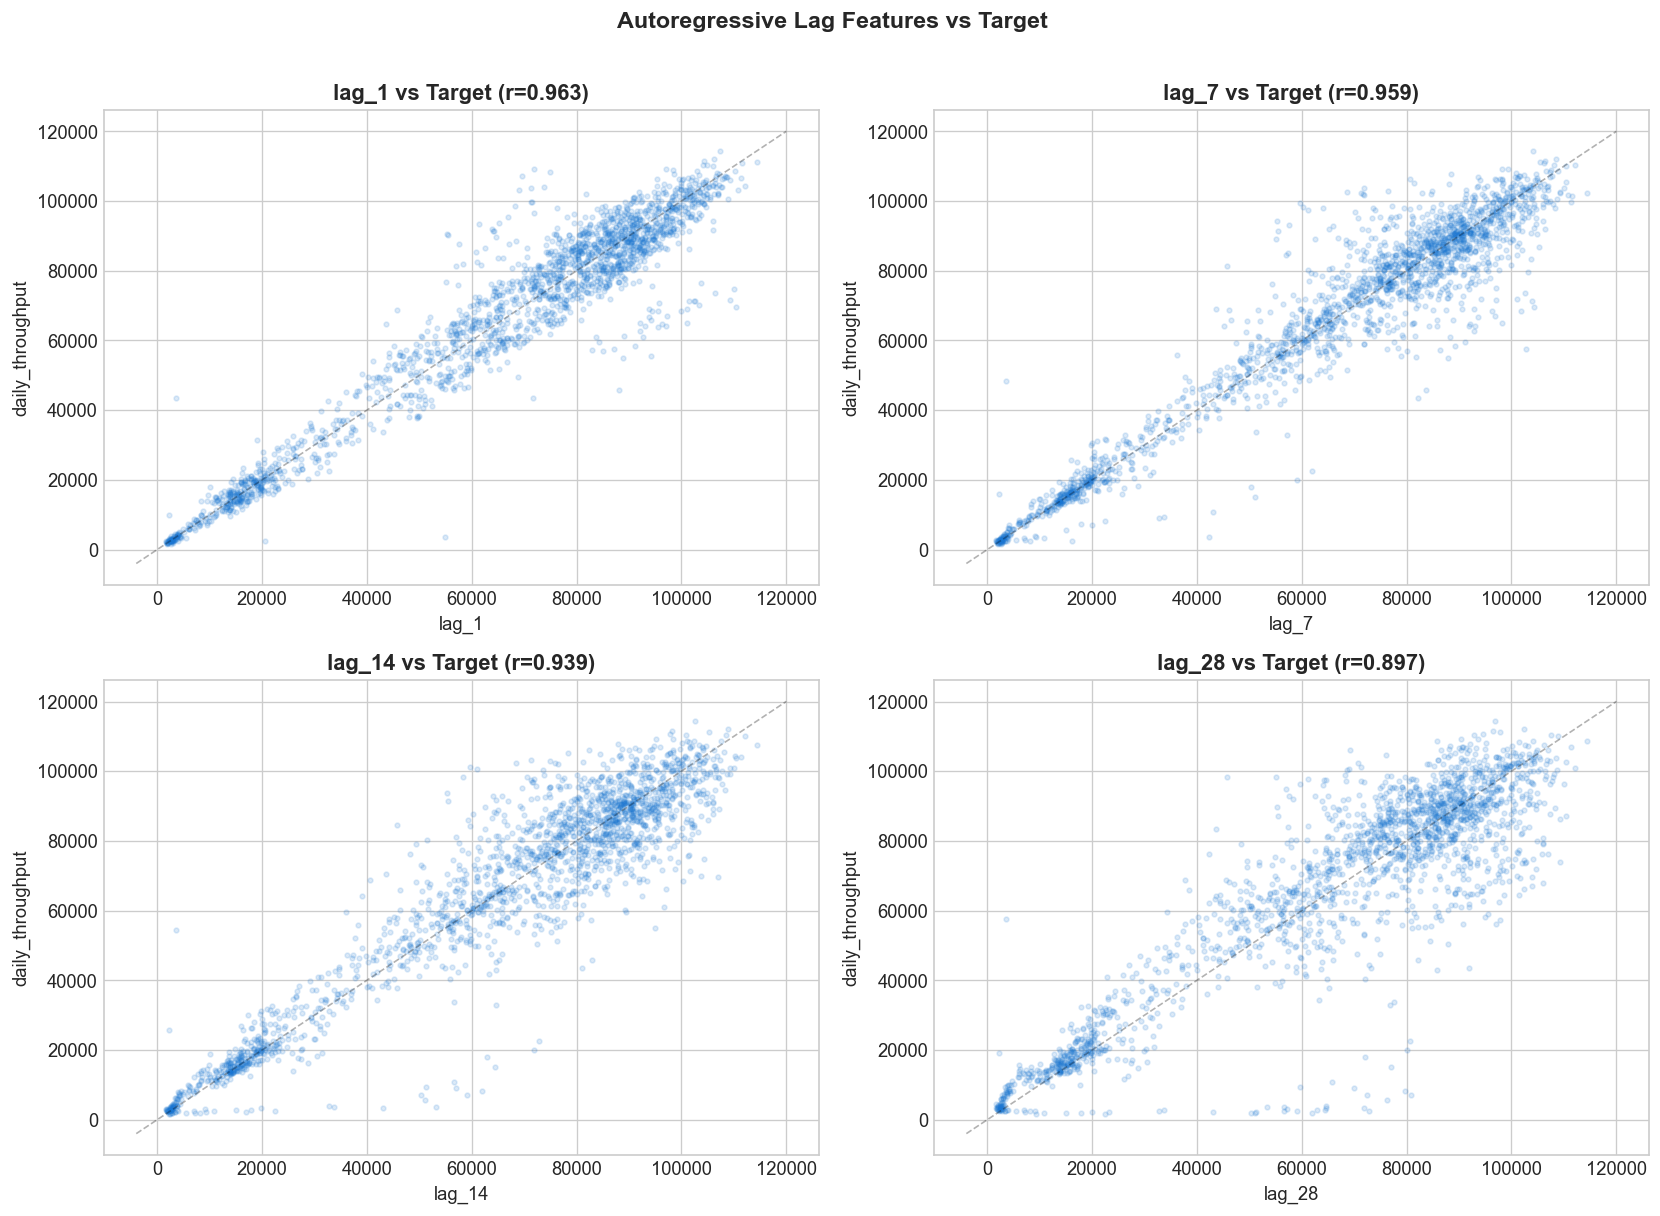

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, lag in zip(axes.flat, [1, 7, 14, 28]):
    col = f'lag_{lag}'
    ax.scatter(df[col], df[target], alpha=0.15, s=8, color='#1976D2')
    ax.set_xlabel(f'lag_{lag}')
    ax.set_ylabel('daily_throughput')
    r = df[[col, target]].corr().iloc[0, 1]
    ax.set_title(f'lag_{lag} vs Target (r={r:.3f})', fontweight='bold')
    # Diagonal reference line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.3, lw=1)

plt.suptitle('Autoregressive Lag Features vs Target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/12_lag_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.3 COVID Regime Comparison

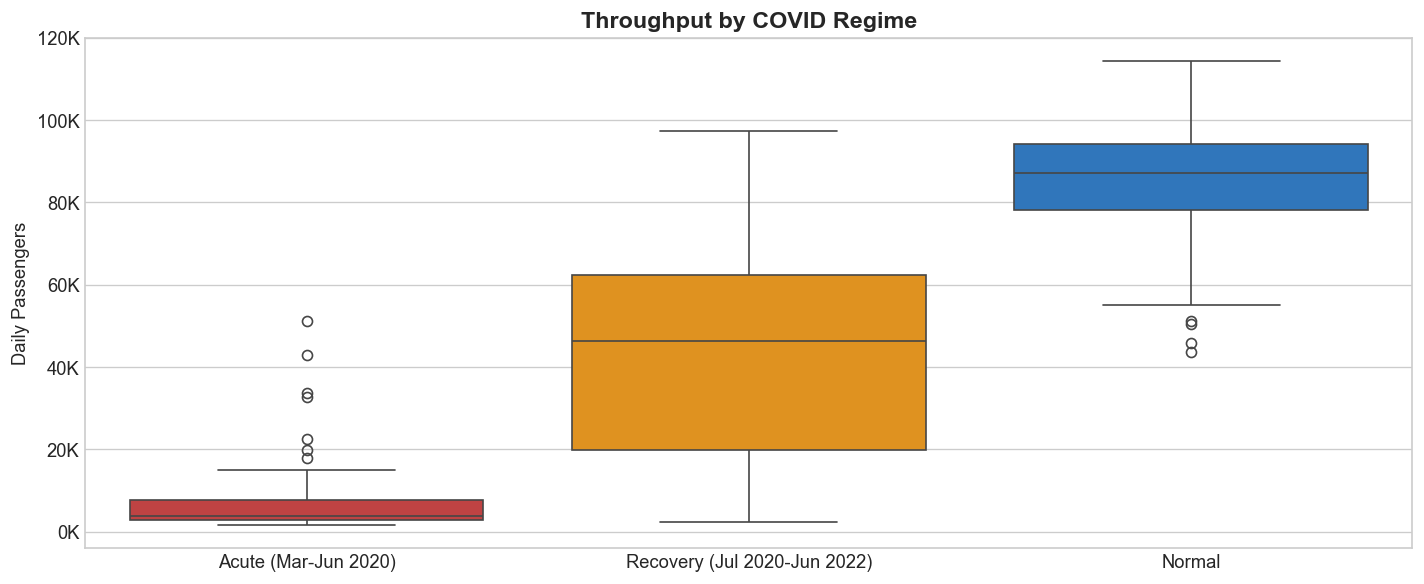

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))

def regime_label(row):
    if row['covid_acute']:
        return 'Acute (Mar-Jun 2020)'
    elif row['covid_recovery']:
        return 'Recovery (Jul 2020-Jun 2022)'
    else:
        return 'Normal'

df['_regime'] = df.apply(regime_label, axis=1)
order = ['Acute (Mar-Jun 2020)', 'Recovery (Jul 2020-Jun 2022)', 'Normal']
palette = {'Acute (Mar-Jun 2020)': '#D32F2F',
           'Recovery (Jul 2020-Jun 2022)': '#FF9800',
           'Normal': '#1976D2'}

sns.boxplot(data=df, x='_regime', y=target, order=order, palette=palette, ax=ax)
ax.set_title('Throughput by COVID Regime', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Daily Passengers')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig(f'{FIGURES}/13_covid_regime_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

df = df.drop(columns=['_regime'])

### 14.4 Holiday Period Effects

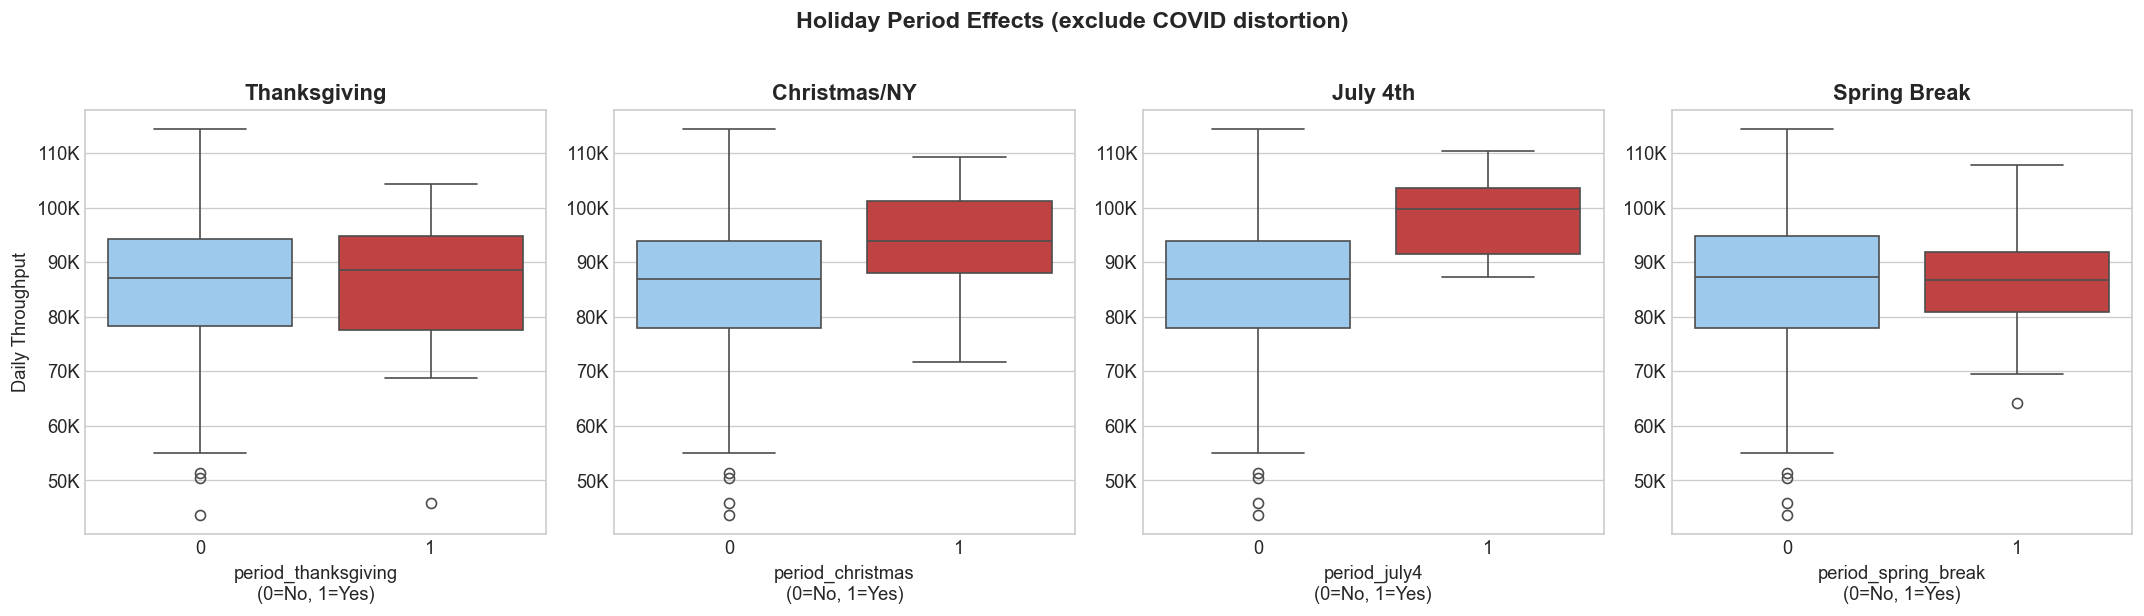

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
period_cols = ['period_thanksgiving', 'period_christmas', 'period_july4', 'period_spring_break']
titles = ['Thanksgiving', 'Christmas/NY', 'July 4th', 'Spring Break']

normal = df[(df['covid_acute'] == 0) & (df['covid_recovery'] == 0)]
for ax, col, title in zip(axes, period_cols, titles):
    # Filter to normal operations only (exclude COVID distortion)
    sns.boxplot(data=normal, x=col, y=target, palette=['#90CAF9', '#D32F2F'], ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'{col}\n(0=No, 1=Yes)')
    ax.set_ylabel('Daily Throughput' if ax == axes[0] else '')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

plt.suptitle('Holiday Period Effects (exclude COVID distortion)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/14_holiday_period_effects.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.5 PCA Explained Variance (Feature Redundancy Check)

With 52 features, many of which are derived from the same throughput signal
(lags, rolling stats, differencing), we expect high redundancy. A PCA
explained variance plot shows how many independent dimensions of information
the feature set actually contains.

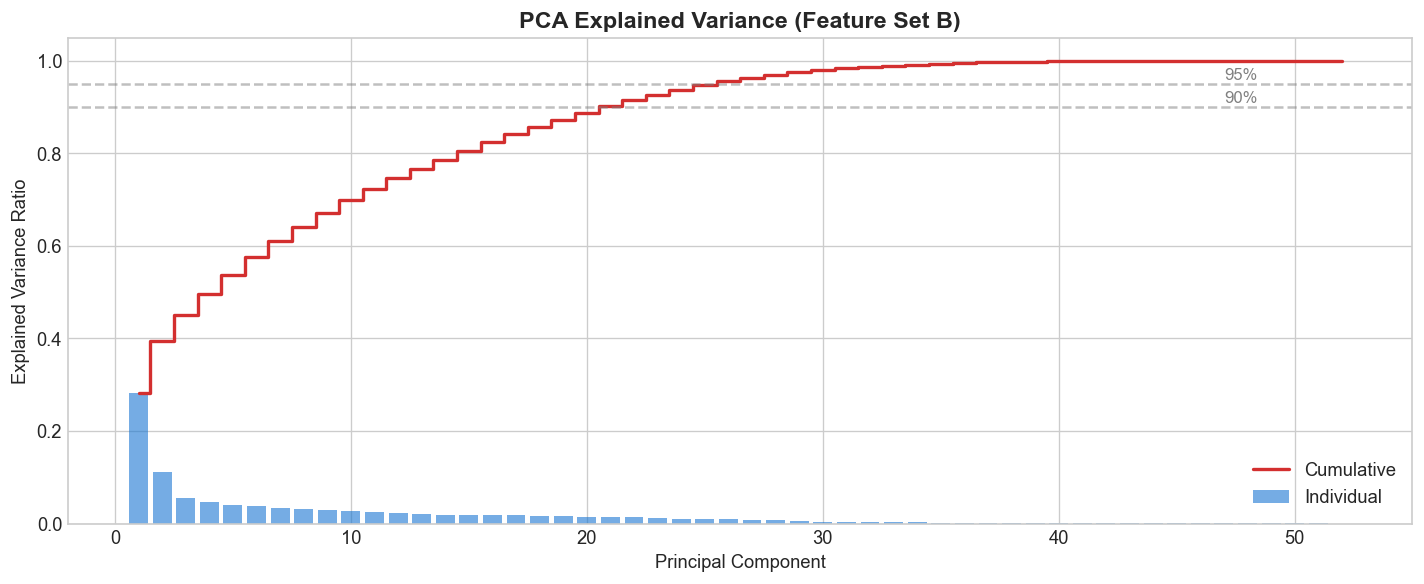

Components for 90% variance: 21 of 52
Components for 95% variance: 26 of 52
Top 5 components explain: 53.8%


In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features (PCA is sensitive to scale)
scaler_pca = StandardScaler()
X_pca = scaler_pca.fit_transform(df[feature_set_B])

# Fit PCA with all components
pca = PCA(n_components=None)
pca.fit(X_pca)

# Explained variance
var_exp = pca.explained_variance_ratio_
cum_var = np.cumsum(var_exp)

# How many components for 90% and 95%?
n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, len(var_exp) + 1), var_exp, alpha=0.6, color='#1976D2',
       label='Individual')
ax.step(range(1, len(var_exp) + 1), cum_var, where='mid', color='#D32F2F',
        lw=2, label='Cumulative')
ax.axhline(0.90, ls='--', color='gray', alpha=0.5)
ax.axhline(0.95, ls='--', color='gray', alpha=0.5)
ax.text(len(var_exp) - 5, 0.91, '90%', fontsize=10, color='gray')
ax.text(len(var_exp) - 5, 0.96, '95%', fontsize=10, color='gray')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Explained Variance (Feature Set B)',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}/15_pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Components for 90% variance: {n_90} of {len(var_exp)}')
print(f'Components for 95% variance: {n_95} of {len(var_exp)}')
print(f'Top 5 components explain: {cum_var[4]:.1%}')

In [27]:
# Loadings for PC1
loadings_pc1 = pd.Series(pca.components_[0], index=feature_set_B)
top5 = loadings_pc1.abs().sort_values(ascending=False).head()
print('Top 5 features by absolute loading on PC1:')
for feat in top5.index:
    print(f'  {feat}: {loadings_pc1[feat]:.4f}')

Top 5 features by absolute loading on PC1:
  roll_max_14: 0.2596
  roll_mean_30: 0.2594
  roll_mean_14: 0.2593
  roll_max_7: 0.2586
  roll_mean_7: 0.2579


 **21 of 52 features are needed to explain 90% of variance**, with no single component dominating (top 5 components cover only 54%). This indicates the feature set contains multiple independent signals, not just one. PC1 is driven by rolling statistics (roll_mean and roll_max at various windows), confirming that recent throughput level is the strongest but not the only signal. The remaining components likely capture calendar patterns, weather effects, and flight schedules.

## 15. Save Model-Ready Dataset

In [ ]:
output_path = '../data/processed/jfk_modeling_ready.csv'
df.to_csv(output_path, index=False)
print(f'Saved: {output_path}')
print(f'  Shape: {df.shape}')
print(f'  Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'  Columns: {list(df.columns)}')

## 16. Summary

| Item | Value |
|------|-------|
| **Input** | `jfk_daily_merged.csv` (2,345 rows x 30 cols) |
| **Output** | `jfk_modeling_ready.csv` (1978 rows x 54 cols) |
| **Feature Set A (SARIMAX)** | Calendar + Holiday + Weather + Flights + COVID |
| **Feature Set B (all others)** | Set A + Lags + Rolling + Differencing + YoY |
| **Feature definitions saved** | `models/feature_sets.json` |